In [1]:
!pip install datasets transformers torch pandas matplotlib spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------------------ --------------------- 5.8/12.8 MB 44.0 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 47.2 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
import re
from datasets import load_dataset
import spacy

d:\MyProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

PHASE2_ANALYSIS = "phase2_analysis.json"  
OUTPUT_JSON = "phase3a_squad_analysis.json"
SAMPLE_SIZE = 50000  # 可以改为 None 使用全部数据

In [3]:

squad = load_dataset("squad_v2")

# 使用训练集进行探索
train_data = squad['train']
val_data = squad['validation']

# 如果设置了样本数，则只使用部分数据
if SAMPLE_SIZE:
    train_sample = train_data.select(range(min(SAMPLE_SIZE, len(train_data))))
else:
    train_sample = train_data

In [4]:
train_sample[0]

{'id': '56be85543aeaaa14008c9063',
 'title': 'Beyoncé',
 'context': 'Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in various singing and dancing competitions as a child, and rose to fame in the late 1990s as lead singer of R&B girl-group Destiny\'s Child. Managed by her father, Mathew Knowles, the group became one of the world\'s best-selling girl groups of all time. Their hiatus saw the release of Beyoncé\'s debut album, Dangerously in Love (2003), which established her as a solo artist worldwide, earned five Grammy Awards and featured the Billboard Hot 100 number-one singles "Crazy in Love" and "Baby Boy".',
 'question': 'When did Beyonce start becoming popular?',
 'answers': {'text': ['in the late 1990s'], 'answer_start': [269]}}

In [5]:

# 问题词统计
question_types = {
    'what': 0,
    'who': 0,
    'when': 0,
    'where': 0,
    'why': 0,
    'how': 0,
    'which': 0,
    'whose': 0,
    'other': 0
}

question_examples = defaultdict(list)

for example in train_sample:
    question = example['question'].lower().strip()
    
    # 识别问题类型
    found = False
    for qtype in ['what', 'who', 'when', 'where', 'why', 'how', 'which', 'whose']:
        if question.startswith(qtype):
            question_types[qtype] += 1
            
            if len(question_examples[qtype]) < 5:
                question_examples[qtype].append({
                    'question': example['question'],
                    'answer': example['answers']['text'][0] if example['answers']['text'] else '[无法回答]'
                })
            
            found = True
            break
    
    if not found:
        question_types['other'] += 1

print(f"\n✓ 问题类型统计完成")

# 显示统计结果
total_questions = sum(question_types.values())

# 排序并显示
sorted_types = sorted(question_types.items(), key=lambda x: x[1], reverse=True)

for qtype, count in sorted_types:
    percentage = (count / total_questions) * 100
    print(f"{qtype.upper():8s}: {count:6,d} ({percentage:5.1f}%)")


for qtype in ['what', 'who', 'when', 'where', 'how']:
    if question_examples[qtype]:
        print(f"\n{qtype.upper()} 问题:")
        for i, ex in enumerate(question_examples[qtype][:2], 1):
            print(f"  {i}. Q: {ex['question']}")
            print(f"     A: {ex['answer']}")


✓ 问题类型统计完成
WHAT    : 21,595 ( 43.2%)
OTHER   : 11,541 ( 23.1%)
WHO     :  5,172 ( 10.3%)
HOW     :  4,083 (  8.2%)
WHEN    :  3,082 (  6.2%)
WHICH   :  2,233 (  4.5%)
WHERE   :  1,808 (  3.6%)
WHY     :    486 (  1.0%)
WHOSE   :      0 (  0.0%)

WHAT 问题:
  1. Q: What areas did Beyonce compete in when she was growing up?
     A: singing and dancing
  2. Q: What album made her a worldwide known artist?
     A: Dangerously in Love

WHO 问题:
  1. Q: Who managed the Destiny's Child group?
     A: Mathew Knowles
  2. Q: Who is Beyoncé married to?
     A: Jay Z

WHEN 问题:
  1. Q: When did Beyonce start becoming popular?
     A: in the late 1990s
  2. Q: When did Beyonce leave Destiny's Child and become a solo singer?
     A: 2003

WHERE 问题:
  1. Q: Where did Beyonce get her name from?
     A: her mother's maiden name
  2. Q: Where did Destiny's Child get their name from?
     A: Book of Isaiah.

HOW 问题:
  1. Q: How many Grammy awards did Beyoncé win for her first solo album?
     A: five
  2. 

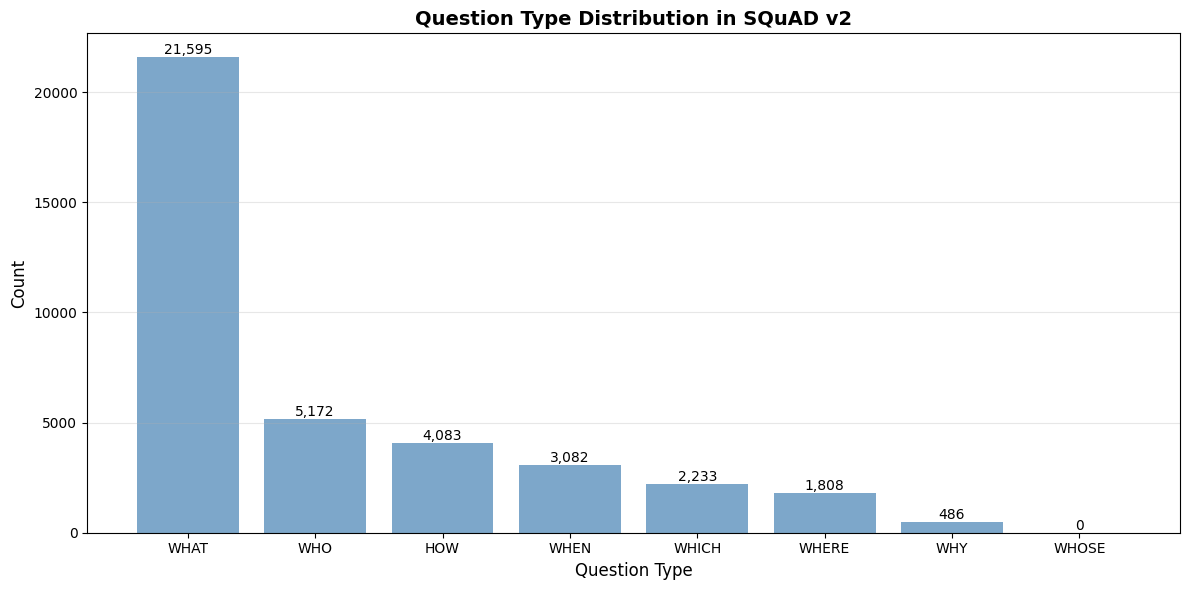

In [6]:
# 创建柱状图
fig, ax = plt.subplots(figsize=(12, 6))

# 准备数据（排除 'other'）
types = [t for t, c in sorted_types if t != 'other']
counts = [c for t, c in sorted_types if t != 'other']

# 绘制
bars = ax.bar(range(len(types)), counts, color='steelblue', alpha=0.7)
ax.set_xticks(range(len(types)))
ax.set_xticklabels([t.upper() for t in types])
ax.set_xlabel('Question Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Question Type Distribution in SQuAD v2', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('squad_question_types.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:

# 统计
answerable_count = 0
unanswerable_count = 0
answer_lengths = []

for example in train_sample:
    if example['answers']['text']:
        answerable_count += 1
        answer = example['answers']['text'][0]
        answer_lengths.append(len(answer.split()))
    else:
        unanswerable_count += 1


print(f"可回答问题: {answerable_count:,} ({answerable_count/len(train_sample)*100:.1f}%)")
print(f"无法回答问题: {unanswerable_count:,} ({unanswerable_count/len(train_sample)*100:.1f}%)")


可回答问题: 35,241 (70.5%)
无法回答问题: 14,759 (29.5%)


In [10]:

nlp = spacy.load("en_core_web_sm")

answer_entities = defaultdict(list)
sample_limit = min(50000, answerable_count)

processed = 0
for example in train_sample:
    if example['answers']['text']:
        answer = example['answers']['text'][0]
        doc = nlp(answer)
        
        for ent in doc.ents:
            answer_entities[ent.label_].append(ent.text)
        
        processed += 1
        if processed >= sample_limit:
            break

# 统计
entity_counts = {label: len(entities) for label, entities in answer_entities.items()}
sorted_entities = sorted(entity_counts.items(), key=lambda x: x[1], reverse=True)

for label, count in sorted_entities[:15]:  # 显示前15种
    percentage = (count / sum(entity_counts.values())) * 100
    print(f"{label:15s}: {count:5d} ({percentage:5.1f}%)")


ORG            :  4505 ( 18.9%)
DATE           :  4494 ( 18.9%)
PERSON         :  4215 ( 17.7%)
CARDINAL       :  3674 ( 15.4%)
GPE            :  2797 ( 11.7%)
NORP           :  1478 (  6.2%)
PERCENT        :   504 (  2.1%)
LOC            :   419 (  1.8%)
ORDINAL        :   365 (  1.5%)
MONEY          :   349 (  1.5%)
QUANTITY       :   219 (  0.9%)
FAC            :   210 (  0.9%)
EVENT          :   157 (  0.7%)
WORK_OF_ART    :   114 (  0.5%)
PRODUCT        :   103 (  0.4%)


In [11]:

# 统计每种问题类型对应的答案实体类型
question_answer_mapping = defaultdict(lambda: defaultdict(int))

sample_limit = min(50000, len(train_sample))

for i, example in enumerate(train_sample):
    if i >= sample_limit:
        break
    
    if not example['answers']['text']:
        continue
    
    question = example['question'].lower().strip()
    answer = example['answers']['text'][0]
    
    # 识别问题类型
    qtype = 'other'
    for qt in ['what', 'who', 'when', 'where', 'why', 'how', 'which', 'whose']:
        if question.startswith(qt):
            qtype = qt
            break
    
    # 识别答案实体
    doc = nlp(answer)
    if doc.ents:
        for ent in doc.ents:
            question_answer_mapping[qtype][ent.label_] += 1
    else:
        question_answer_mapping[qtype]['NO_ENTITY'] += 1


# 显示主要映射关系

for qtype in ['who', 'when', 'where', 'what']:
    if qtype in question_answer_mapping:
        print(f"\n{qtype.upper()} 问题的答案类型:")
        
        entities = question_answer_mapping[qtype]
        sorted_entities = sorted(entities.items(), key=lambda x: x[1], reverse=True)[:5]
        
        total = sum(entities.values())
        for entity_type, count in sorted_entities:
            percentage = (count / total) * 100
            print(f"  {entity_type:15s}: {count:4d} ({percentage:5.1f}%)")


WHO 问题的答案类型:
  PERSON         : 1807 ( 48.6%)
  NO_ENTITY      :  762 ( 20.5%)
  ORG            :  629 ( 16.9%)
  NORP           :  219 (  5.9%)
  GPE            :  218 (  5.9%)

WHEN 问题的答案类型:
  DATE           : 1767 ( 78.6%)
  NO_ENTITY      :  162 (  7.2%)
  CARDINAL       :  149 (  6.6%)
  ORG            :   64 (  2.8%)
  EVENT          :   26 (  1.2%)

WHERE 问题的答案类型:
  GPE            :  498 ( 33.3%)
  NO_ENTITY      :  375 ( 25.1%)
  ORG            :  216 ( 14.4%)
  PERSON         :  127 (  8.5%)
  LOC            :   94 (  6.3%)

WHAT 问题的答案类型:
  NO_ENTITY      : 7551 ( 48.2%)
  ORG            : 2317 ( 14.8%)
  PERSON         : 1255 (  8.0%)
  GPE            : 1027 (  6.6%)
  DATE           :  856 (  5.5%)


In [12]:

phase2_data = None

with open(PHASE2_ANALYSIS, 'r', encoding='utf-8') as f:
    phase2_data = json.load(f)
 

if phase2_data:
    # 对比问题词
    if 'question_words' in phase2_data:
        print("\n问题类型对比:")
        print(f"{'类型':10s} {'Phase 2':>15s} {'SQuAD':>15s}")
        print("-" * 45)
        
        for qtype in ['who', 'what', 'when', 'where', 'how']:
            phase2_count = phase2_data['question_words'].get(qtype, {}).get('count', 0)
            squad_count = question_types.get(qtype, 0)
            print(f"{qtype.upper():10s} {phase2_count:>15,d} {squad_count:>15,d}")
    
    # 对比实体
    if 'entities' in phase2_data:
        print("\n实体类型对比:")
        print(f"{'类型':15s} {'Phase 2':>15s} {'SQuAD':>15s}")
        print("-" * 50)
        
        for entity_type in ['PERSON', 'DATE', 'GPE', 'ORG']:
            phase2_count = phase2_data['entities'].get(entity_type, {}).get('count', 0)
            squad_count = entity_counts.get(entity_type, 0)
            print(f"{entity_type:15s} {phase2_count:>15,d} {squad_count:>15,d}")
    


问题类型对比:
类型                 Phase 2           SQuAD
---------------------------------------------
WHO                    111           5,172
WHAT                    70          21,595
WHEN                    76           3,082
WHERE                   41           1,808
HOW                     63           4,083

实体类型对比:
类型                      Phase 2           SQuAD
--------------------------------------------------
PERSON                      330           4,215
DATE                        113           4,494
GPE                         112           2,797
ORG                         137           4,505


In [ ]:


context_lengths = []

for example in train_sample:
    context = example['context']
    context_lengths.append(len(context.split()))

print("\n上下文统计:")
print("="*80)
print(f"平均长度: {np.mean(context_lengths):.1f} 词")
print(f"中位数: {np.median(context_lengths):.1f} 词")
print(f"最短: {np.min(context_lengths)} 词")
print(f"最长: {np.max(context_lengths)} 词")




上下文统计:
平均长度: 109.1 词
中位数: 101.0 词
最短: 20 词
最长: 499 词


In [15]:

analysis_results = {
    'metadata': {
        'dataset': 'SQuAD v2',
        'total_train': len(train_data),
        'total_validation': len(val_data),
        'analyzed_samples': len(train_sample)
    },
    'question_types': {
        'distribution': dict(question_types),
        'examples': {k: v for k, v in question_examples.items()}
    },
    'answers': {
        'answerable': answerable_count,
        'unanswerable': unanswerable_count,
        'avg_length': float(np.mean(answer_lengths)) if answer_lengths else 0,
        'median_length': float(np.median(answer_lengths)) if answer_lengths else 0,
        'entity_types': dict(entity_counts)
    },
    'contexts': {
        'avg_length': float(np.mean(context_lengths)),
        'median_length': float(np.median(context_lengths))
    },
    'question_answer_mapping': {
        qtype: dict(entities) 
        for qtype, entities in question_answer_mapping.items()
    }
}

with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(analysis_results, f, ensure_ascii=False, indent=2)

print(f"✓ 分析结果已保存: {OUTPUT_JSON}")

✓ 分析结果已保存: phase3a_squad_analysis.json


In [18]:

print(f"\n✓ 分析概览")
print(f"  数据集: SQuAD v2")
print(f"  训练集: {len(train_data):,} 条")
print(f"  验证集: {len(val_data):,} 条")
print(f"  分析样本: {len(train_sample):,} 条")

print(f"\n✓ 主要发现")
print(f"  1. 问题类型分布:")
for qtype, count in sorted_types[:3]:
    if qtype != 'other':
        print(f"     - {qtype.upper()}: {count:,} ({count/total_questions*100:.1f}%)")

print(f"\n  2. 答案特征:")
print(f"     - 可回答: {answerable_count:,} ({answerable_count/len(train_sample)*100:.1f}%)")
print(f"     - 无法回答: {unanswerable_count:,} ({unanswerable_count/len(train_sample)*100:.1f}%)")
if answer_lengths:
    print(f"     - 平均答案长度: {np.mean(answer_lengths):.1f} 词")

print(f"\n  3. 答案实体类型:")
for label, count in sorted_entities[:3]:
    print(f"     - {label}: {count:,}")

print(f"\n  4. 问题-答案映射:")
print(f"     - WHO → PERSON (人名)")
print(f"     - WHEN → DATE (时间)")
print(f"     - WHERE → GPE (地点)")
print(f"     - WHAT → 多种类型")





✓ 分析概览
  数据集: SQuAD v2
  训练集: 130,319 条
  验证集: 11,873 条
  分析样本: 50,000 条

✓ 主要发现
  1. 问题类型分布:
     - WHAT: 21,595 (43.2%)
     - WHO: 5,172 (10.3%)

  2. 答案特征:
     - 可回答: 35,241 (70.5%)
     - 无法回答: 14,759 (29.5%)
     - 平均答案长度: 2.6 词

  3. 答案实体类型:
     - NO_ENTITY: 7,551
     - ORG: 2,317
     - PERSON: 1,255

  4. 问题-答案映射:
     - WHO → PERSON (人名)
     - WHEN → DATE (时间)
     - WHERE → GPE (地点)
     - WHAT → 多种类型
